In [147]:
import xgboost as xgb
from xgboost import XGBClassifier
import catboost
from catboost import Pool, CatBoostClassifier
from catboost.utils import get_confusion_matrix

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [149]:
from sklearn import tree
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingClassifier

In [150]:
# работает через direct_url
standart_url = 'https://drive.google.com/file/d/1AUkzlUCbBKgj-whxLxxBUIs28FUcxYJa/view?usp=drive_link'
direct_url = 'https://drive.google.com/uc?export=view&id=1AUkzlUCbBKgj-whxLxxBUIs28FUcxYJa'

data_load = pd.read_csv(direct_url)

In [151]:
df = data_load.copy()
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [152]:
df.shape

(103904, 25)

In [153]:
df['satisfaction'].describe()

count                      103904
unique                          2
top       neutral or dissatisfied
freq                        58879
Name: satisfaction, dtype: object

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [155]:
df = df.drop(columns='Unnamed: 0')

In [156]:
df.isna().sum().sum()

310

In [157]:
df.columns

Index(['id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [158]:
# Задание 6.2

df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())
df['Arrival Delay in Minutes'].mean()

15.133392362180475

In [159]:
df['Arrival Delay in Minutes'].describe()

count    103904.000000
mean         15.133392
std          38.649776
min           0.000000
25%           0.000000
50%           0.000000
75%          13.000000
max        1584.000000
Name: Arrival Delay in Minutes, dtype: float64

<Axes: ylabel='Arrival Delay in Minutes'>

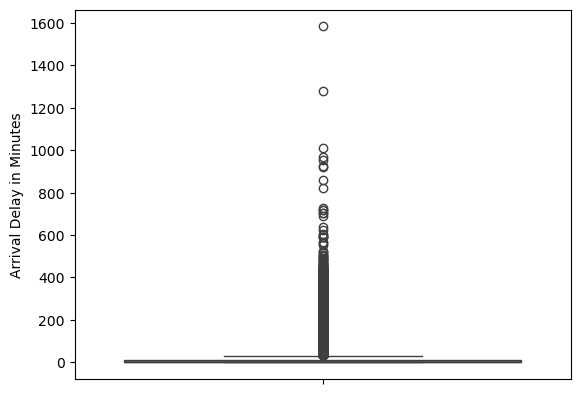

In [160]:
sns.boxplot(df['Arrival Delay in Minutes'])

<Axes: xlabel='satisfaction', ylabel='Count'>

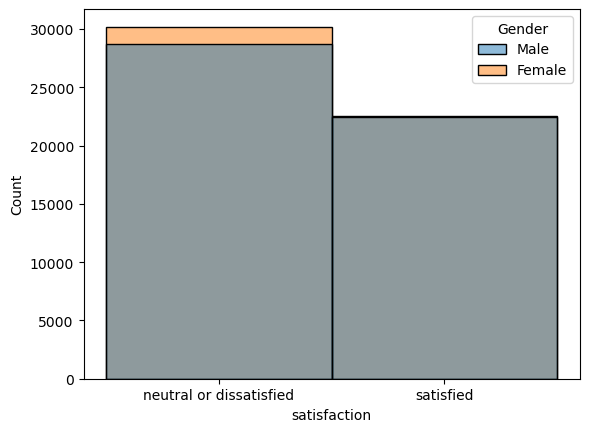

In [161]:
sns.histplot(
    data=df,
    x=df['satisfaction'],
    hue=df['Gender'],
)

In [162]:
# sns.pairplot(df);

In [163]:
# sns.pairplot(
#     data=df, 
#     aspect=.85,
#     hue='satisfaction'); # hue='cat_col' подсвечивает указанную категорию другим цветом.

In [164]:
# Задание 6.3

# 1.

df.groupby('Gender')['satisfaction'].value_counts() / df.shape[0]

Gender  satisfaction           
Female  neutral or dissatisfied    0.290586
        satisfied                  0.216873
Male    neutral or dissatisfied    0.276082
        satisfied                  0.216459
Name: count, dtype: float64

In [165]:
# 2.

df.groupby('Type of Travel')['satisfaction'].value_counts() / df.shape[0]

Type of Travel   satisfaction           
Business travel  satisfied                  0.401775
                 neutral or dissatisfied    0.287852
Personal Travel  neutral or dissatisfied    0.278815
                 satisfied                  0.031558
Name: count, dtype: float64

In [166]:
# 3.

df.groupby('Class')['satisfaction'].value_counts() / df.shape[0]

Class     satisfaction           
Business  satisfied                  0.331845
          neutral or dissatisfied    0.146145
Eco       neutral or dissatisfied    0.366146
          satisfied                  0.083741
Eco Plus  neutral or dissatisfied    0.054377
          satisfied                  0.017747
Name: count, dtype: float64

Перекодируем часть бинарных признаков, чтобы использовать их при обучении:


In [167]:
df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied':0 , 'satisfied':1})
df['Customer Type'] = df['Customer Type'].map({'Loyal Customer':1, 'disloyal Customer':0})
df['Type of Travel'] = df['Type of Travel'].map({'Personal Travel':0, 'Business travel':1})
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [168]:
# Задание 6.4

df=pd.get_dummies(df)
df.shape

(103904, 26)

In [169]:
# делим выборку на фичи и таргет
target = 'satisfaction'
y = df[target]
X = df.drop(columns=target)

In [170]:
# Задание 6.5

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=26)
y_test.shape

(20781,)

**Задание 6.6**

Теперь нам необходимо реализовать масштабирование данных. Для этого обучите на обучающей выборке метод StandardScaler() и с помощью него преобразуйте и обучающую, и тестовую выборки. Не забудьте, что целевую переменную обрабатывать не нужно.

Примечание. Отметим, что если бы дальше мы работали только с деревьями, масштабирование бы не требовалось. Однако мы реализуем его, чтобы можно было обучать и другие модели и сравнивать полученные результаты.

В качестве ответа введите самое первое значение из матрицы преобразованных признаков тестовой выборки. Округлите значение до двух знаков после точки-разделителя.

In [171]:
# Задание 6.6

scaler = StandardScaler()
scaler.fit(X_train) 
X_train = scaler.transform(X_train) 
X_test = scaler.transform(X_test) 
X_test[0][0]

0.9408251379303

In [172]:
X_test

array([[ 0.94082514, -1.0182236 ,  0.47381845, ...,  1.04624209,
        -0.90523003, -0.27897268],
       [-0.86687265,  0.98210256,  0.47381845, ...,  1.04624209,
        -0.90523003, -0.27897268],
       [-1.63303947,  0.98210256, -2.11051299, ..., -0.95580173,
         1.10469159, -0.27897268],
       ...,
       [ 1.52620083, -1.0182236 , -2.11051299, ..., -0.95580173,
         1.10469159, -0.27897268],
       [-0.60330678, -1.0182236 ,  0.47381845, ..., -0.95580173,
         1.10469159, -0.27897268],
       [ 1.34108544, -1.0182236 ,  0.47381845, ...,  1.04624209,
        -0.90523003, -0.27897268]])

**Задание 6.7**

Перейдём к обучению моделей. В качестве первой модели возьмём самую простую — логистическую регрессию. Мы делаем это для того, чтобы потом сравнивать с ней полученные результаты: так вы сможете выяснить, насколько ансамбли смогут улучшить точность прогноза.

Обучите логистическую регрессию с параметрами по умолчанию на наших данных. В качестве ответа введите значение метрики f1_score. Ответ округлите до трёх знаков после точки-разделителя.

In [173]:
# Задание 6.7

model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)
preds_test = model_lr.predict(X_test)
f1_score(preds_test, y_test)

0.8547046934650797

**Задание 6.8**

Теперь перейдём к бустингу. Начнём с обучения первой модели — AdaBoost. В качестве базовой модели для неё возьмите решающее дерево с параметром random_state = 26.

Обучите AdaBoost, зафиксировав random_state со значением 26 и задав темп обучения 0.01. В качестве ответа введите значение метрики f1_score. Ответ округлите до трёх знаков после точки-разделителя.

In [174]:
# Задание 6.8

model_ada = AdaBoostClassifier(DecisionTreeClassifier(random_state=26),random_state=26,learning_rate=0.01)

model_ada.fit(X_train, y_train)
preds_test = model_ada.predict(X_test)
f1_score(preds_test, y_test)

0.9404794558121674

**Задание 6.9**

Перейдем к следующему алгоритму — градиентному бустингу.

Будем настраивать количество деревьев и темп обучения, делая перебор по следующей сетке:

```params = {"n_estimators":2**np.arange(8), "learning_rate":0.1**np.arange(3)}```

Используйте для поиска оптимальных параметров GridSearchCV, а для ускорения работы алгоритма задайте параметр кросс-валидации, равный 3.

Какое наибольшее значение метрики f1_score получилось? Ответ округлите до трёх знаков после точки-разделителя.

Примечание. Необходимо указать лучший результат в методе GridSearchCV на тренировочных данных.

In [175]:
# Задание 6.9

model_for_gs = GradientBoostingClassifier()
params = {"n_estimators":2**np.arange(8), "learning_rate":0.1**np.arange(3)}
gs = GridSearchCV(model_for_gs, 
                  params, 
                  cv=3, 
                  scoring=make_scorer(f1_score),
                  verbose=5,
                 )
 
gs.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV 1/3] END .learning_rate=1.0, n_estimators=1;, score=0.873 total time=   0.2s
[CV 2/3] END .learning_rate=1.0, n_estimators=1;, score=0.870 total time=   0.2s
[CV 3/3] END .learning_rate=1.0, n_estimators=1;, score=0.871 total time=   0.2s
[CV 1/3] END .learning_rate=1.0, n_estimators=2;, score=0.880 total time=   0.4s
[CV 2/3] END .learning_rate=1.0, n_estimators=2;, score=0.878 total time=   0.4s
[CV 3/3] END .learning_rate=1.0, n_estimators=2;, score=0.875 total time=   0.3s
[CV 1/3] END .learning_rate=1.0, n_estimators=4;, score=0.901 total time=   0.7s
[CV 2/3] END .learning_rate=1.0, n_estimators=4;, score=0.896 total time=   0.7s
[CV 3/3] END .learning_rate=1.0, n_estimators=4;, score=0.897 total time=   0.7s
[CV 1/3] END .learning_rate=1.0, n_estimators=8;, score=0.920 total time=   1.4s
[CV 2/3] END .learning_rate=1.0, n_estimators=8;, score=0.920 total time=   1.3s
[CV 3/3] END .learning_rate=1.0, n_estimators=8;

,estimator,GradientBoostingClassifier()
,param_grid,"{'learning_rate': array([1. , 0.1 , 0.01]), 'n_estimators': array([ 1, ...32, 64, 128])}"
,scoring,make_scorer(f...hod='predict')
,n_jobs,None
,refit,True
,cv,3
,verbose,5
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [176]:
print("Лучшие гиперпараметры:", gs.best_params_)
print("Лучшее значение метрики:", gs.best_score_)

Лучшие гиперпараметры: {'learning_rate': 1.0, 'n_estimators': 128}
Лучшее значение метрики: 0.9491538177771582


In [177]:
# Задание 6.10

model_xgb = XGBClassifier(random_state=26)
model_xgb.fit(X_train,y_train)
preds_test = model_xgb.predict(X_test)
f1_score(preds_test, y_test)

0.9573723114544546

In [178]:
# Задание 6.11

model = CatBoostClassifier(random_state=26)
model.fit(X_train, y_train)
preds_class = model.predict(X_test)

Learning rate set to 0.068023
0:	learn: 0.6018254	total: 44.2ms	remaining: 44.2s
1:	learn: 0.5020788	total: 68.8ms	remaining: 34.3s
2:	learn: 0.4472506	total: 110ms	remaining: 36.5s
3:	learn: 0.4028683	total: 135ms	remaining: 33.6s
4:	learn: 0.3674742	total: 165ms	remaining: 32.9s
5:	learn: 0.3397838	total: 196ms	remaining: 32.4s
6:	learn: 0.3121236	total: 231ms	remaining: 32.7s
7:	learn: 0.2917493	total: 271ms	remaining: 33.6s
8:	learn: 0.2749031	total: 319ms	remaining: 35.1s
9:	learn: 0.2575194	total: 349ms	remaining: 34.6s
10:	learn: 0.2473688	total: 373ms	remaining: 33.5s
11:	learn: 0.2377536	total: 406ms	remaining: 33.4s
12:	learn: 0.2279307	total: 458ms	remaining: 34.7s
13:	learn: 0.2212511	total: 503ms	remaining: 35.4s
14:	learn: 0.2100355	total: 528ms	remaining: 34.7s
15:	learn: 0.2025734	total: 569ms	remaining: 35s
16:	learn: 0.1942301	total: 612ms	remaining: 35.4s
17:	learn: 0.1877938	total: 677ms	remaining: 36.9s
18:	learn: 0.1832382	total: 744ms	remaining: 38.4s
19:	learn: 

In [179]:
f1_score(preds_class, y_test)

0.959822172825785

In [180]:
# Задание 6.12

cm = get_confusion_matrix(model, Pool(X_train, y_train))

In [195]:
cm

array([[46668.,   538.],
       [ 1255., 34662.]])

In [201]:
cm.sum()

83123.0

In [202]:
cm_percent = cm / cm.sum()

In [200]:
X_train.shape

(83123, 25)

<Axes: >

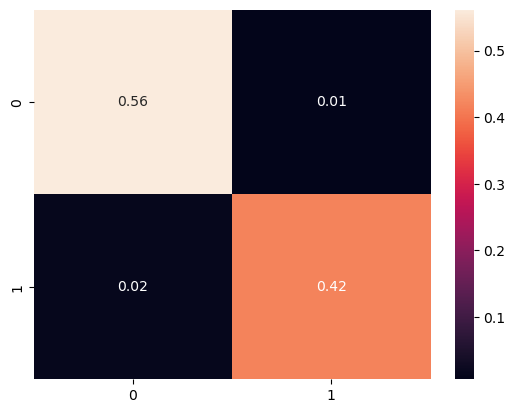

In [203]:
sns.heatmap(cm_percent, annot=True, fmt=".2f")

In [205]:
# Задание 6.13

pd.DataFrame(
    {
        "feature_importance": model.get_feature_importance(),
        "feature_names": df.drop(columns="satisfaction").columns,
    }
).sort_values(by=["feature_importance"], ascending=False)

,feature_importance,feature_names
6,25.260967,Inflight wifi service
4,18.532444,Type of Travel
2,7.373753,Customer Type
11,7.331027,Online boarding
22,5.520561,Class_Business
17,3.864023,Checkin service
3,3.791612,Age
16,3.586852,Baggage handling
9,3.283956,Gate location
12,2.971680,Seat comfort
